In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
import joblib
import os
import json

In [3]:
df = pd.read_csv("..//data//TSLA.csv")

In [4]:
# ── STEP 1: Use only Adj Close ─────────────────────────────
data = df[['Adj Close']].copy()

# ── STEP 2: Scale (LSTM needs 0-1 range) ───────────────────
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# ── STEP 3: Chronological split BEFORE windowing ───────────
split_idx  = int(len(data_scaled) * 0.80)
train_data = data_scaled[:split_idx]
test_data  = data_scaled[split_idx:]

In [5]:
# ── STEP 4: Create sliding windows ─────────────────────────
WINDOW = 30   # 30 days lookback

def make_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])   # past 30 days
        y.append(data[i, 0])            # next day
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_data, WINDOW)
X_test,  y_test  = make_sequences(test_data,  WINDOW)

# ── STEP 5: Reshape to 3D for LSTM ─────────────────────────
# (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],   X_test.shape[1],  1)

print(f"X_train shape : {X_train.shape}")   # (samples, 30, 1)
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")

X_train shape : (1902, 30, 1)
X_test shape  : (454, 30, 1)
y_train shape : (1902,)


In [6]:

# ── STEP 6: Build model ─────────────────────────────────────
model = Sequential()
model.add(LSTM(64, return_sequences=True,
               input_shape=(WINDOW, 1)))
model.add(LSTM(32, return_sequences=False))
model.add(Dense(16))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# ── STEP 7: Train ───────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs          = 100,
    batch_size      = 32,
    validation_split= 0.1,
    callbacks       = [early_stop],
    verbose         = 1
)

C:\Users\Parth\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - loss: 0.0027 - val_loss: 7.3606e-04
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 2.3514e-04 - val_loss: 6.1319e-04
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.1647e-04 - val_loss: 5.3716e-04
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.0967e-04 - val_loss: 5.8921e-04
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1.9660e-04 - val_loss: 4.8901e-04
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1.8183e-04 - val_loss: 4.7153e-04
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 1.6279e-04 - val_loss: 5.8785e-04
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 1.5029e-04 - val_loss: 4.6717e-04
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 1.3806e-04 - val_loss: 4.1366e-04
Epoch 10/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1.3959e-04 - val_loss: 0.0012
Epoch 11/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 1.288

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step  

── LSTM Results ──
  R2   : 0.9696
  MAE  : 7.7435
  RMSE : 12.8888
  MAPE : 2.50%


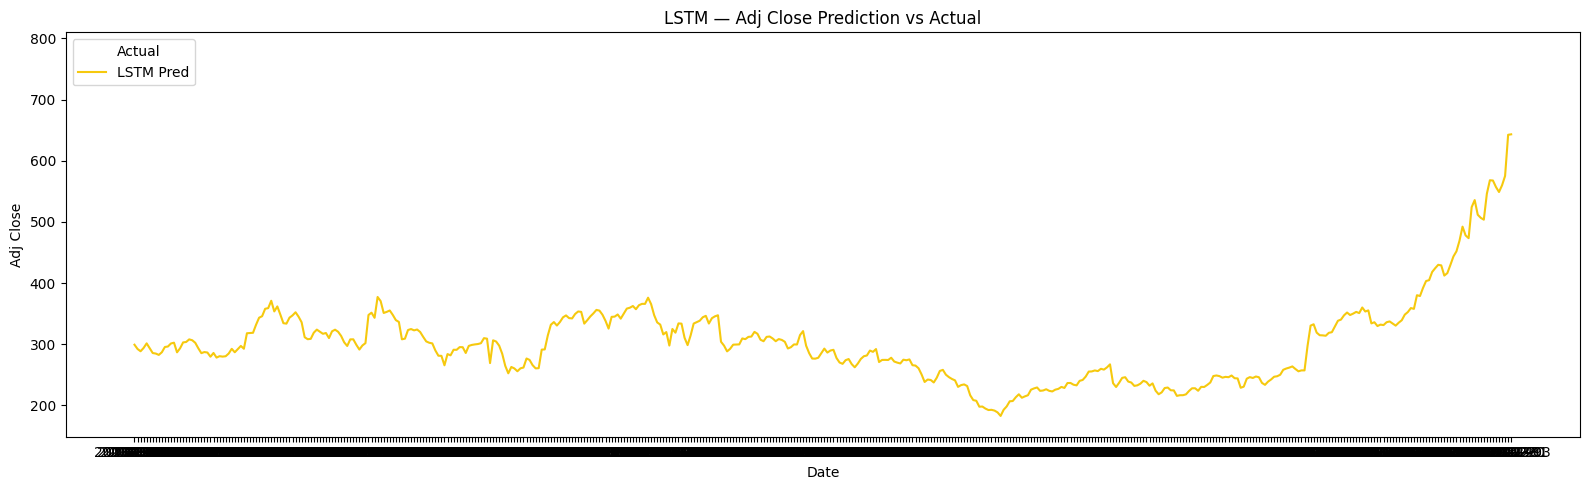

In [7]:
# ── STEP 8: Predict + inverse scale ────────────────────────
preds_scaled = model.predict(X_test)
preds        = scaler.inverse_transform(preds_scaled)
y_actual     = scaler.inverse_transform(y_test.reshape(-1, 1))

# ── STEP 9: Evaluate ────────────────────────────────────────

mae  = mean_absolute_error(y_actual, preds)
rmse = np.sqrt(mean_squared_error(y_actual, preds))
mape = np.mean(np.abs((y_actual - preds) / y_actual)) * 100
r2   = r2_score(y_actual, preds)

print(f"\n── LSTM Results ──")
print(f"  R2   : {r2:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAPE : {mape:.2f}%")

# ── STEP 10: Plot ───────────────────────────────────────────
import matplotlib.pyplot as plt

dates_lstm = df['Date'].iloc[split_idx + WINDOW:].reset_index(drop=True)

plt.figure(figsize=(16, 5))
plt.plot(dates_lstm, y_actual,  label='Actual',    linewidth=2,   color='white')
plt.plot(dates_lstm, preds,     label='LSTM Pred', linewidth=1.5, color='#f6c90e')
plt.title('LSTM — Adj Close Prediction vs Actual')
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()
plt.tight_layout()
plt.show()

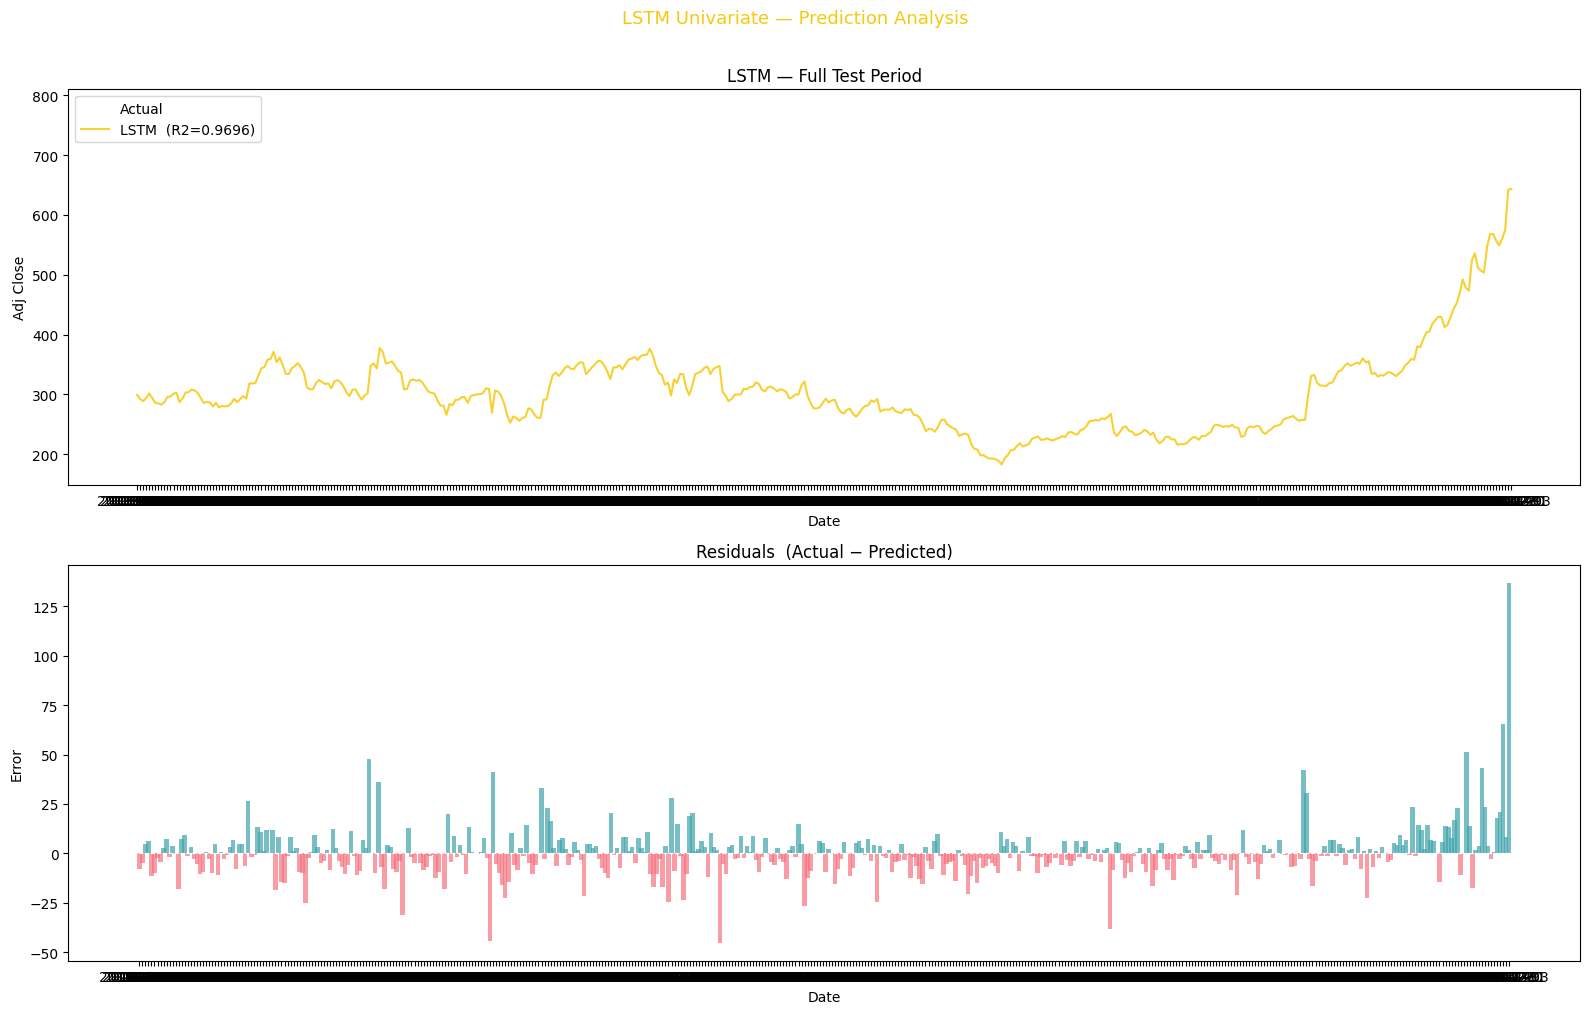

In [8]:
dates_lstm = df['Date'].iloc[split_idx + WINDOW:].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ── Plot 1: Full test period ───────────────────────────────
axes[0].plot(dates_lstm, y_actual, label='Actual',
             linewidth=2, color='white')
axes[0].plot(dates_lstm, preds,    label=f'LSTM  (R2={r2:.4f})',
             linewidth=1.5, color='#f6c90e', alpha=0.85)
axes[0].set_title('LSTM — Full Test Period')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Adj Close')
axes[0].legend()

# ── Plot 2: Residuals (actual - predicted) ─────────────────
residuals = y_actual.flatten() - preds.flatten()
axes[1].bar(dates_lstm, residuals,
            color=np.where(residuals >= 0, '#3da4ab', '#f67280'),
            alpha=0.7, width=1.5)
axes[1].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set_title('Residuals  (Actual − Predicted)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Error')

plt.suptitle('LSTM Univariate — Prediction Analysis', fontsize=13,
             color='#f6c90e', y=1.01)
plt.tight_layout()
plt.show()

## **Multivariate**

In [9]:
# ── Features to use ────────────────────────────────────────
mv_features = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
N_FEATURES  = len(mv_features)
WINDOW      = 30

# ── Scale each feature independently ───────────────────────
mv_scaler   = MinMaxScaler()
mv_data     = mv_scaler.fit_transform(df[mv_features].values)

# ── Target scaler separately (for inverse transform) ───────
target_col_idx = mv_features.index('Adj Close')

target_scaler_mv = MinMaxScaler()
target_scaler_mv.fit(df[['Adj Close']].values)

# ── Chronological split ─────────────────────────────────────
mv_split     = int(len(mv_data) * 0.80)
mv_train     = mv_data[:mv_split]
mv_test      = mv_data[mv_split:]

In [10]:
# ── Sliding window — all features as input ─────────────────
def make_sequences_mv(data, window, target_idx):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, :])       # all features, past 30 days
        y.append(data[i, target_idx])       # only Adj Close as target
    return np.array(X), np.array(y)

X_train_mv, y_train_mv = make_sequences_mv(mv_train, WINDOW, target_col_idx)
X_test_mv,  y_test_mv  = make_sequences_mv(mv_test,  WINDOW, target_col_idx)

print(f"X_train_mv shape : {X_train_mv.shape}")  # (samples, 30, 6)
print(f"X_test_mv  shape : {X_test_mv.shape}")

X_train_mv shape : (1902, 30, 6)
X_test_mv  shape : (454, 30, 6)


In [11]:

# ── Build multivariate model ────────────────────────────────
mv_model = Sequential()
mv_model.add(LSTM(64, return_sequences=True,
                  input_shape=(WINDOW, N_FEATURES)))
mv_model.add(LSTM(32, return_sequences=False))
mv_model.add(Dense(16))
mv_model.add(Dense(1))

mv_model.compile(optimizer='adam', loss='mean_squared_error')
mv_model.summary()

# ── Train ───────────────────────────────────────────────────
early_stop_mv = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_mv = mv_model.fit(
    X_train_mv, y_train_mv,
    epochs           = 100,
    batch_size       = 32,
    validation_split = 0.1,
    callbacks        = [early_stop_mv],
    verbose          = 1
)

C:\Users\Parth\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 30, 64)              │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - loss: 0.0020 - val_loss: 5.1488e-04
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 1.9690e-04 - val_loss: 5.3979e-04
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 1.7628e-04 - val_loss: 5.6194e-04
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1.6139e-04 - val_loss: 5.9830e-04
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1.7686e-04 - val_loss: 4.6365e-04
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 1.5532e-04 - val_loss: 4.2176e-04
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1.4923e-04 - val_loss: 4.9912e-04
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 1.4219e-04 - val_loss: 3.9857e-04
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 1.3219e-04 - val_loss: 0.0011
Epoch 10/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 1.2468e-04 - val_loss: 5.6456e-04
Epoch 11/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 1.133

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step  

── Multivariate LSTM Results ──
  R2   : 0.9649
  MAE  : 8.0198
  RMSE : 13.8399
  MAPE : 2.56%


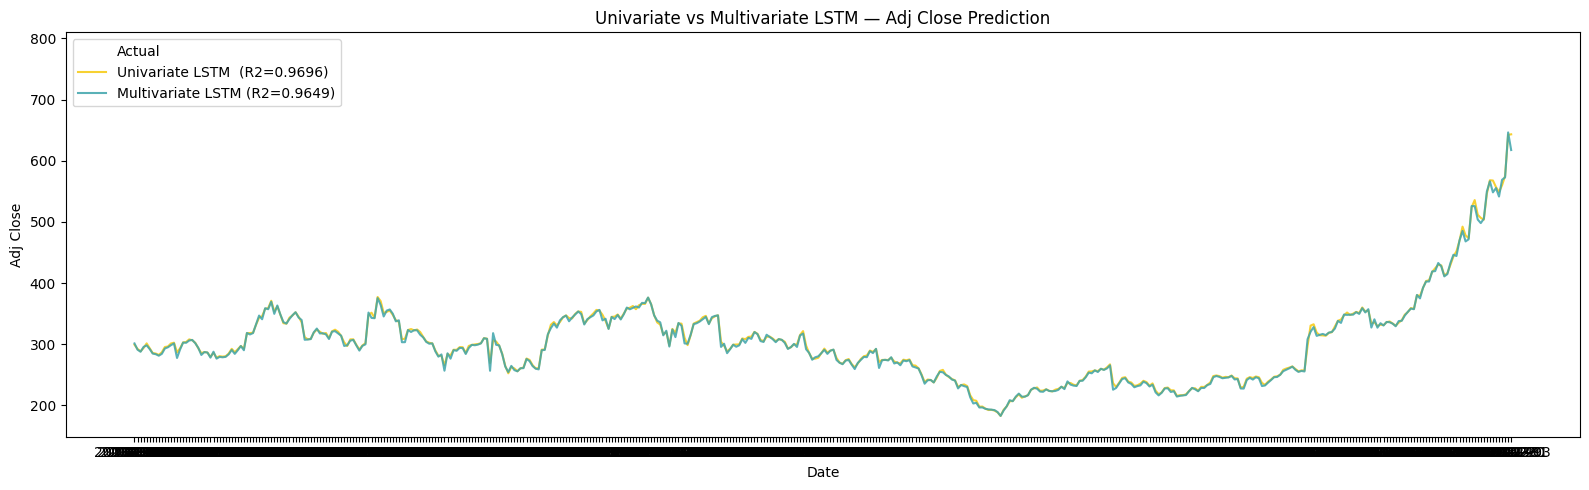


══════════════════════════════════════════════════════════════════════
  LSTM COMPARISON
══════════════════════════════════════════════════════════════════════
  Model                           R2      MAE     RMSE    MAPE%
──────────────────────────────────────────────────────────────────────
  Univariate LSTM             0.9696   7.7435  12.8888     2.50%
  Multivariate LSTM           0.9649   8.0198  13.8399     2.56%
──────────────────────────────────────────────────────────────────────

  Winner : Univariate LSTM
══════════════════════════════════════════════════════════════════════



In [12]:
# ── Predict + inverse scale ─────────────────────────────────
preds_mv_scaled = mv_model.predict(X_test_mv)
preds_mv        = target_scaler_mv.inverse_transform(preds_mv_scaled)
y_actual_mv     = target_scaler_mv.inverse_transform(y_test_mv.reshape(-1, 1))

# ── Evaluate ────────────────────────────────────────────────
mae_mv  = mean_absolute_error(y_actual_mv, preds_mv)
rmse_mv = np.sqrt(mean_squared_error(y_actual_mv, preds_mv))
mape_mv = np.mean(np.abs((y_actual_mv - preds_mv) / y_actual_mv)) * 100
r2_mv   = r2_score(y_actual_mv, preds_mv)

print(f"\n── Multivariate LSTM Results ──")
print(f"  R2   : {r2_mv:.4f}")
print(f"  MAE  : {mae_mv:.4f}")
print(f"  RMSE : {rmse_mv:.4f}")
print(f"  MAPE : {mape_mv:.2f}%")

# ── Plot univariate vs multivariate ────────────────────────
dates_mv = df['Date'].iloc[mv_split + WINDOW:].reset_index(drop=True)

plt.figure(figsize=(16, 5))
plt.plot(dates_mv, y_actual_mv,
         label='Actual', linewidth=2, color='white')
plt.plot(dates_lstm, preds,
         label=f'Univariate LSTM  (R2={r2:.4f})',
         linewidth=1.5, color='#f6c90e', alpha=0.85)
plt.plot(dates_mv, preds_mv,
         label=f'Multivariate LSTM (R2={r2_mv:.4f})',
         linewidth=1.5, color='#3da4ab', alpha=0.85)
plt.title('Univariate vs Multivariate LSTM — Adj Close Prediction')
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()
plt.tight_layout()
plt.show()

# ── Final comparison ────────────────────────────────────────
W = 70
print(f"\n{'═' * W}")
print(f"  LSTM COMPARISON")
print(f"{'═' * W}")
print(f"  {'Model':<25} {'R2':>8} {'MAE':>8} {'RMSE':>8} {'MAPE%':>8}")
print(f"{'─' * W}")
print(f"  {'Univariate LSTM':<25} {r2:>8.4f} {mae:>8.4f} {rmse:>8.4f} {mape:>8.2f}%")
print(f"  {'Multivariate LSTM':<25} {r2_mv:>8.4f} {mae_mv:>8.4f} {rmse_mv:>8.4f} {mape_mv:>8.2f}%")
print(f"{'─' * W}")
winner = 'Univariate' if r2 > r2_mv else 'Multivariate'
print(f"\n  Winner : {winner} LSTM")
print(f"{'═' * W}\n")

$$ \LARGE \text{Save Model} $$

In [20]:
SAVE_DIR = 'models'
os.makedirs(f"..//{SAVE_DIR}", exist_ok=True)

# ══════════════════════════════════════════════════════════════
# STEP 2 — SAVE LSTM MODEL + SCALER
# ══════════════════════════════════════════════════════════════

model.save(f'..//{SAVE_DIR}//lstm_univariate.keras')
joblib.dump(scaler, f'..//{SAVE_DIR}//lstm_scaler.pkl')
print("✓ LSTM model saved")
print("✓ LSTM scaler saved")

# ══════════════════════════════════════════════════════════════
# STEP 3 — SAVE METADATA
# ══════════════════════════════════════════════════════════════

metadata = {
    'window_size'    : WINDOW,
    'features_lstm'  : ['Adj Close'],
    'split_ratio'    : 0.80,
    'results': {
        'LSTM_Uni' : {'R2': 0.9696, 'MAE':  7.7435, 'RMSE': 12.8888, 'MAPE': 2.50},
        'LSTM_Multi': {'R2': 0.9649, 'MAE': 8.0198, 'RMSE': 13.8399, 'MAPE': 2.56},
    },
    'best_model'     : 'LSTM Univariate',
    'target_column'  : 'Adj Close',
    'dataset_rows'   : len(df),
}

with open(f'..//{SAVE_DIR}//metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print("✓ Metadata saved")

✓ LSTM model saved
✓ LSTM scaler saved
✓ Metadata saved
